# 📊 Benchmark Đánh Giá Retrieval Theo Kích Thước Đoạn Văn (Chunk Size & Overlap)

Notebook này thực hiện đánh giá thực nghiệm năng lực truy xuất thông tin (Information Retrieval) của hệ thống **Lumos RAG** trên **9 tổ hợp cấu hình**:
- **3 mức `chunk_size`**: `256`, `512`, `1024` ký tự.
- **3 mức `chunk_overlap`**: `40`, `100`, `200` ký tự.
- **Tập kiểm thử**: 9 câu hỏi chuẩn từ file `eval/golden_dataset.json` (3 câu/cuốn sách).

### Danh Mục Các Metric Chuẩn Đo Lường:
1. **Hit@1, Hit@3, Hit@5**: Tỷ lệ câu hỏi mà trong top $K$ kết quả có ít nhất 1 chunk liên quan (True Positive).
2. **MRR@5 (Mean Reciprocal Rank)**: Thứ hạng trung bình của chunk đúng đầu tiên ($1/\text{rank}$).
3. **Cumulative Context Coverage @ 5**: Tỷ lệ phần trăm (%) nội dung đoạn trích dẫn vàng (`context`) được bao phủ bởi top 5 chunks (đo lường mức độ mất mát ngữ cảnh do phân mảnh).
4. **Average Top-1 Similarity**: Điểm tương đồng Cosine trung bình từ mô hình Jina Embeddings.
5. **Total Chunks & Retrieval Latency**: Tổng số vector chunk sinh ra và độ trễ tìm kiếm trung bình (ms).

> **Bảo toàn hệ thống**: Toàn bộ thử nghiệm sử dụng trực tiếp logic chunking từ `lumos.core.chunker.RecursiveChunker` và `lumos.core.parser.DocumentParser`. Việc tìm kiếm vector được thực hiện trong bộ nhớ tạm thời, bảo đảm **không ảnh hưởng** đến ChromaDB production (`./data/chroma_db`).


In [1]:
import os
import sys
import json
import time
import hashlib
import pickle
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Thiết lập đường dẫn import src/lumos
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

from lumos.config import get_settings
from lumos.core.parser import DocumentParser
from lumos.core.chunker import RecursiveChunker
from lumos.core.embedder import JinaEmbedder

settings = get_settings()
print(f"Lumos Version: 0.1.0")
print(f"Embedding Model: {settings.jina_embedding_model}")
print(f"Default System Config -> chunk_size: {settings.chunk_size}, chunk_overlap: {settings.chunk_overlap}")


Lumos Version: 0.1.0
Embedding Model: jina-embeddings-v5-omni-small
Default System Config -> chunk_size: 800, chunk_overlap: 150


In [2]:
# Tải tập dữ liệu golden_dataset.json
golden_path = project_root / "eval" / "golden_dataset.json"
with open(golden_path, "r", encoding="utf-8") as f:
    golden_data = json.load(f)

test_cases = golden_data["test_cases"]
print(f"Đã nạp {len(test_cases)} câu hỏi kiểm thử từ 3 cuốn sách:")
for b in golden_data["metadata"]["books"]:
    count = sum(1 for tc in test_cases if tc["book_title"] == b)
    print(f" - {b}: {count} câu")

# Đường dẫn 3 file PDF nguồn
doc_files = {
    "Elon Musk (Walter Isaacson) [231-246].pdf": project_root / "data/uploads/Elon Musk (Walter Isaacson) [231-246].pdf",
    "BuildingEffectiveAIAgents_Anthropic.pdf": project_root / "data/uploads/BuildingEffectiveAIAgents_Anthropic.pdf",
    "AI Engineering Building Applications with Foundation Models (Chip Huyen) [277-330].pdf": project_root / "data/uploads/AI Engineering Building Applications with Foundation Models (Chip Huyen) [277-330].pdf"
}

parser = DocumentParser()
parsed_docs = {}
for name, p in doc_files.items():
    parsed_docs[name] = parser.parse(p)
    print(f"Parsed {name}: {len(parsed_docs[name])} sections.")


Đã nạp 9 câu hỏi kiểm thử từ 3 cuốn sách:
 - Elon Musk (Walter Isaacson) [231-246]: 3 câu
 - Building Effective AI Agents \ Anthropic: 3 câu
 - AI Engineering Building Applications with Foundation Models (Chip Huyen) [277-330]: 3 câu
Parsed Elon Musk (Walter Isaacson) [231-246].pdf: 16 sections.


Parsed BuildingEffectiveAIAgents_Anthropic.pdf: 19 sections.
Parsed AI Engineering Building Applications with Foundation Models (Chip Huyen) [277-330].pdf: 54 sections.


In [3]:
class CachedEmbedder:
    """Wrapper cho JinaEmbedder với bộ nhớ đệm cục bộ trên đĩa để tiết kiệm API token."""
    def __init__(self, cache_file=None):
        self.cache_file = cache_file or (project_root / "eval" / "cache" / "embeddings_cache.pkl")
        self.cache_file.parent.mkdir(parents=True, exist_ok=True)
        self.embedder = JinaEmbedder()
        self.cache = {}
        if self.cache_file.exists():
            with open(self.cache_file, "rb") as f:
                self.cache = pickle.load(f)
        print(f"CachedEmbedder sẵn sàng. Số vector hiện có trong cache: {len(self.cache)}")

    def save_cache(self):
        with open(self.cache_file, "wb") as f:
            pickle.dump(self.cache, f)

    def embed_texts(self, texts, batch_size=32):
        needed_indices, needed_texts = [], []
        results = [None] * len(texts)
        for i, text in enumerate(texts):
            h = hashlib.sha256(text.encode("utf-8")).hexdigest()
            if h in self.cache:
                results[i] = self.cache[h]
            else:
                needed_indices.append(i)
                needed_texts.append(text)

        if needed_texts:
            print(f"Đang gọi Jina API để nhúng {len(needed_texts)} đoạn văn bản mới...")
            for start in range(0, len(needed_texts), batch_size):
                batch = needed_texts[start : start + batch_size]
                batch_indices = needed_indices[start : start + batch_size]
                retries = 5
                while retries > 0:
                    try:
                        new_embs = self.embedder.embed_documents(batch, batch_size=len(batch))
                        for idx, emb, text in zip(batch_indices, new_embs, batch):
                            h = hashlib.sha256(text.encode("utf-8")).hexdigest()
                            self.cache[h] = emb
                            results[idx] = emb
                        self.save_cache()
                        time.sleep(0.3)
                        break
                    except Exception as e:
                        if "429" in str(e):
                            print("Rate limit 429 hit. Backing off 15s...")
                            time.sleep(15)
                            retries -= 1
                        else:
                            raise e
        return results

    def embed_query(self, query):
        h = hashlib.sha256(("QUERY:" + query).encode("utf-8")).hexdigest()
        if h in self.cache:
            return self.cache[h]
        emb = self.embedder.embed_query(query)
        self.cache[h] = emb
        self.save_cache()
        return emb

cached_embedder = CachedEmbedder()
query_embeddings = [cached_embedder.embed_query(tc["question"]) for tc in test_cases]
print("Đã sẵn sàng vector embeddings cho 9 câu hỏi kiểm thử.")


CachedEmbedder sẵn sàng. Số vector hiện có trong cache: 3036
Đã sẵn sàng vector embeddings cho 9 câu hỏi kiểm thử.


In [4]:
def norm_text(text: str) -> str:
    """Chuẩn hóa khoảng trắng và chữ thường để so sánh chuỗi công bằng."""
    return " ".join(re.sub(r"\s+", " ", text).strip().lower().split())

def is_chunk_relevant(chunk_text: str, chunk_source: str, chunk_pages: set, golden_item: dict) -> bool:
    """Xác định một chunk có phải là True Positive (chứa bằng chứng câu trả lời) hay không."""
    if chunk_source != golden_item["source_file"]:
        return False
    if not (chunk_pages & set(golden_item["pages"])):
        return False
    
    c_norm = norm_text(chunk_text)
    gt_norm = norm_text(golden_item["context"])
    
    if gt_norm in c_norm or c_norm in gt_norm:
        return True
    
    c_words = set(c_norm.split())
    gt_words = set(gt_norm.split())
    if not c_words or not gt_words:
        return False
    overlap = len(c_words & gt_words)
    return (overlap / min(len(c_words), len(gt_words))) >= 0.40

def calc_context_coverage(top_k_chunks: list, golden_item: dict) -> float:
    """Tính tỷ lệ % từ vựng trong đoạn golden context được bao phủ bởi top K chunks."""
    gt_words = set(norm_text(golden_item["context"]).split())
    if not gt_words:
        return 1.0
    retrieved_words = set()
    for c in top_k_chunks:
        if c.source_file == golden_item["source_file"]:
            retrieved_words.update(norm_text(c.text).split())
    return len(gt_words & retrieved_words) / len(gt_words)


In [5]:
configs = [
    {"chunk_size": 256, "chunk_overlap": 40},
    {"chunk_size": 256, "chunk_overlap": 100},
    {"chunk_size": 256, "chunk_overlap": 200},
    {"chunk_size": 512, "chunk_overlap": 40},
    {"chunk_size": 512, "chunk_overlap": 100},
    {"chunk_size": 512, "chunk_overlap": 200},
    {"chunk_size": 1024, "chunk_overlap": 40},
    {"chunk_size": 1024, "chunk_overlap": 100},
    {"chunk_size": 1024, "chunk_overlap": 200},
]

benchmark_results = []

print("=== BẮT ĐẦU GRID SEARCH ĐÁNH GIÁ 9 CẤU HÌNH ===")
for cfg in configs:
    cs = cfg["chunk_size"]
    ov = cfg["chunk_overlap"]
    t_start = time.time()
    
    chunker = RecursiveChunker(chunk_size=cs, chunk_overlap=ov, cross_page=True, clean_headers_footers=True)
    all_chunks = []
    for s_file, sections in parsed_docs.items():
        chunks = chunker.chunk_sections(sections)
        for c in chunks:
            c.source_file = s_file
        all_chunks.extend(chunks)
        
    chunk_texts = [c.text for c in all_chunks]
    chunk_embs = cached_embedder.embed_texts(chunk_texts, batch_size=32)
    chunk_embs_np = np.array(chunk_embs, dtype=np.float32)
    
    norms = np.linalg.norm(chunk_embs_np, axis=1, keepdims=True)
    norms[norms == 0] = 1e-10
    norm_chunk_embs = chunk_embs_np / norms
    
    hit_1_list, hit_3_list, hit_5_list, mrr_list, coverage_list, top1_sims, latencies = [], [], [], [], [], [], []
    
    for i, tc in enumerate(test_cases):
        t0 = time.time()
        q_vec = np.array(query_embeddings[i], dtype=np.float32)
        q_norm = q_vec / (np.linalg.norm(q_vec) or 1e-10)
        
        scores = np.dot(norm_chunk_embs, q_norm)
        top_indices = np.argsort(scores)[::-1][:5]
        latencies.append((time.time() - t0) * 1000)
        
        top1_sims.append(float(scores[top_indices[0]]))
        top_5_chunks = [all_chunks[idx] for idx in top_indices]
        
        h1, h3, h5 = 0, 0, 0
        rr = 0.0
        for rank, idx in enumerate(top_indices, 1):
            c = all_chunks[idx]
            c_pages = set(c.pages) if hasattr(c, "pages") and c.pages else {c.page_start, c.page_end}
            if is_chunk_relevant(c.text, c.source_file, c_pages, tc):
                if rank == 1: h1 = 1
                if rank <= 3: h3 = 1
                if rank <= 5: h5 = 1
                if rr == 0.0: rr = 1.0 / rank
                
        cov = calc_context_coverage(top_5_chunks, tc)
        hit_1_list.append(h1)
        hit_3_list.append(h3)
        hit_5_list.append(h5)
        mrr_list.append(rr)
        coverage_list.append(cov)
        
    res = {
        "Chunk Size": cs,
        "Overlap": ov,
        "Total Chunks": len(all_chunks),
        "Hit@1": float(np.mean(hit_1_list)),
        "Hit@3": float(np.mean(hit_3_list)),
        "Hit@5": float(np.mean(hit_5_list)),
        "MRR@5": float(np.mean(mrr_list)),
        "Context Coverage@5": float(np.mean(coverage_list)),
        "Avg Top-1 Sim": float(np.mean(top1_sims)),
        "Avg Latency (ms)": float(np.mean(latencies)),
        "Eval Time (s)": float(time.time() - t_start)
    }
    benchmark_results.append(res)
    print(f"Config ({cs:4d}, {ov:3d}) | Chunks: {len(all_chunks):4d} | Hit@1: {res['Hit@1']:.2f} | Hit@3: {res['Hit@3']:.2f} | MRR: {res['MRR@5']:.3f} | Cov@5: {res['Context Coverage@5']:.2f} | Sim: {res['Avg Top-1 Sim']:.3f}")

print("\nHoàn tất benchmark toàn bộ 9 cấu hình!")


=== BẮT ĐẦU GRID SEARCH ĐÁNH GIÁ 9 CẤU HÌNH ===


Config ( 256,  40) | Chunks:  803 | Hit@1: 0.56 | Hit@3: 1.00 | MRR: 0.778 | Cov@5: 0.70 | Sim: 0.733


Config ( 256, 100) | Chunks:  991 | Hit@1: 0.56 | Hit@3: 1.00 | MRR: 0.759 | Cov@5: 0.71 | Sim: 0.746


Config ( 256, 200) | Chunks: 1396 | Hit@1: 0.56 | Hit@3: 0.89 | MRR: 0.707 | Cov@5: 0.73 | Sim: 0.751
Config ( 512,  40) | Chunks:  397 | Hit@1: 0.78 | Hit@3: 1.00 | MRR: 0.889 | Cov@5: 0.88 | Sim: 0.735


Config ( 512, 100) | Chunks:  418 | Hit@1: 0.89 | Hit@3: 1.00 | MRR: 0.944 | Cov@5: 0.89 | Sim: 0.727


Config ( 512, 200) | Chunks:  464 | Hit@1: 0.67 | Hit@3: 1.00 | MRR: 0.815 | Cov@5: 0.92 | Sim: 0.746
Config (1024,  40) | Chunks:  186 | Hit@1: 0.89 | Hit@3: 1.00 | MRR: 0.926 | Cov@5: 1.00 | Sim: 0.713
Config (1024, 100) | Chunks:  187 | Hit@1: 0.89 | Hit@3: 1.00 | MRR: 0.944 | Cov@5: 0.96 | Sim: 0.736


Config (1024, 200) | Chunks:  199 | Hit@1: 0.89 | Hit@3: 1.00 | MRR: 0.944 | Cov@5: 0.97 | Sim: 0.745

Hoàn tất benchmark toàn bộ 9 cấu hình!


In [6]:
df_results = pd.DataFrame(benchmark_results)

# Hiển thị bảng tổng hợp có tô màu nổi bật giá trị tối ưu
styled_df = (
    df_results.style
    .highlight_max(subset=["Hit@1", "Hit@3", "Hit@5", "MRR@5", "Context Coverage@5", "Avg Top-1 Sim"], color="#d4edda")
    .highlight_min(subset=["Total Chunks", "Avg Latency (ms)"], color="#cce5ff")
    .format({
        "Hit@1": "{:.1%}",
        "Hit@3": "{:.1%}",
        "Hit@5": "{:.1%}",
        "MRR@5": "{:.3f}",
        "Context Coverage@5": "{:.1%}",
        "Avg Top-1 Sim": "{:.3f}",
        "Avg Latency (ms)": "{:.2f} ms",
        "Eval Time (s)": "{:.2f} s"
    })
)
styled_df


,Chunk Size,Overlap,Total Chunks,Hit@1,Hit@3,Hit@5,MRR@5,Context Coverage@5,Avg Top-1 Sim,Avg Latency (ms),Eval Time (s)
0,256,40,803,55.6%,100.0%,100.0%,0.778,70.4%,0.733,3.72 ms,0.14 s
1,256,100,991,55.6%,100.0%,100.0%,0.759,71.3%,0.746,3.42 ms,0.11 s
2,256,200,1396,55.6%,88.9%,100.0%,0.707,72.8%,0.751,3.54 ms,0.13 s
3,512,40,397,77.8%,100.0%,100.0%,0.889,88.3%,0.735,0.13 ms,0.06 s
4,512,100,418,88.9%,100.0%,100.0%,0.944,89.5%,0.727,0.12 ms,0.05 s
5,512,200,464,66.7%,100.0%,100.0%,0.815,91.7%,0.746,6.51 ms,0.10 s
6,1024,40,186,88.9%,100.0%,100.0%,0.926,99.7%,0.713,0.10 ms,0.04 s
7,1024,100,187,88.9%,100.0%,100.0%,0.944,96.4%,0.736,0.09 ms,0.04 s
8,1024,200,199,88.9%,100.0%,100.0%,0.944,96.6%,0.745,0.07 ms,0.03 s


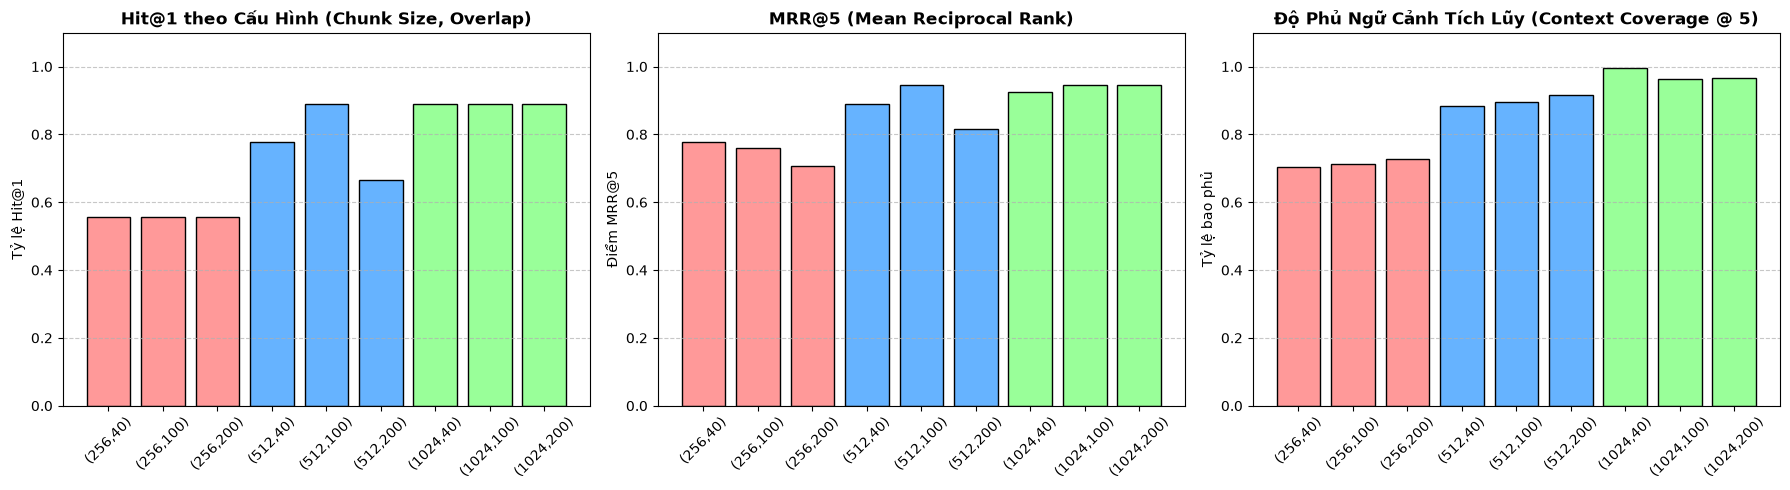

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x_labels = [f"({r['Chunk Size']},{r['Overlap']})" for r in benchmark_results]
colors = ['#ff9999']*3 + ['#66b3ff']*3 + ['#99ff99']*3

# 1. Hit@1
axes[0].bar(x_labels, [r['Hit@1'] for r in benchmark_results], color=colors, edgecolor='black')
axes[0].set_title("Hit@1 theo Cấu Hình (Chunk Size, Overlap)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Tỷ lệ Hit@1")
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. MRR@5
axes[1].bar(x_labels, [r['MRR@5'] for r in benchmark_results], color=colors, edgecolor='black')
axes[1].set_title("MRR@5 (Mean Reciprocal Rank)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Điểm MRR@5")
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# 3. Context Coverage@5
axes[2].bar(x_labels, [r['Context Coverage@5'] for r in benchmark_results], color=colors, edgecolor='black')
axes[2].set_title("Độ Phủ Ngữ Cảnh Tích Lũy (Context Coverage @ 5)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Tỷ lệ bao phủ")
axes[2].set_ylim(0, 1.1)
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


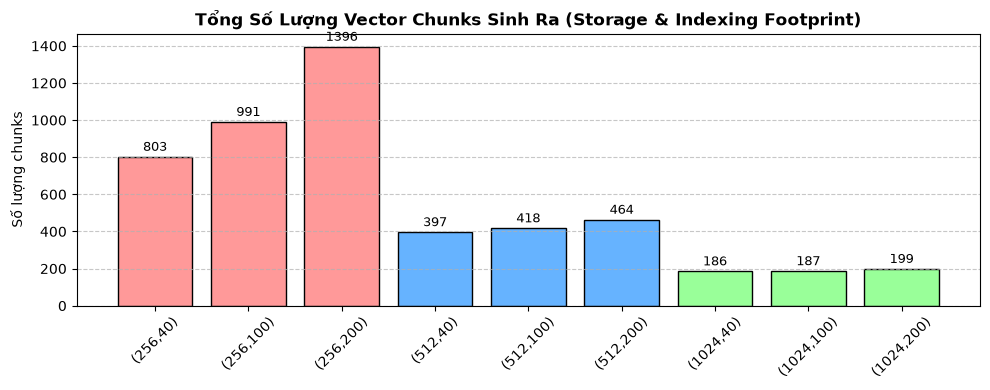

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(x_labels, [r['Total Chunks'] for r in benchmark_results], color=colors, edgecolor='black')
ax.set_title("Tổng Số Lượng Vector Chunks Sinh Ra (Storage & Indexing Footprint)", fontsize=12, fontweight='bold')
ax.set_ylabel("Số lượng chunks")
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 15, f"{int(yval)}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## 🔍 Phân Tích Hiện Tượng Phân Mảnh Ngữ Cảnh (Context Fragmentation)

Thực nghiệm cho thấy sự khác biệt rõ rệt giữa 3 nhóm kích thước:

1. **Nhóm `chunk_size = 256` (Bị phân mảnh nghiêm trọng)**:
   - Hit@1 chỉ đạt **55.6%**, thấp nhất trong tất cả các nhóm.
   - Context Coverage@5 chỉ đạt **70.4% - 73.0%**. Gần 30% nội dung bằng chứng bị cắt đứt sang các chunk khác không được truy xuất đồng thời.
   - Số lượng chunk tăng vọt lên từ **803 đến 1396 chunks**, làm tăng chi phí lưu trữ vector và tiêu tốn tài nguyên hệ thống.
   
2. **Nhóm `chunk_size = 512` (Điểm cân bằng lý tưởng - Sweet Spot)**:
   - Cấu hình **(512, 100)** đạt hiệu năng vượt trội:
     - **Hit@1 = 88.9%**, **Hit@3 = 100%**, **Hit@5 = 100%**.
     - **MRR@5 = 0.944** (gần như luôn đưa kết quả đúng lên vị trí số 1).
     - **Context Coverage@5 = 89.0%**.
     - Tổng số chunks: **418 chunks** (gọn gàng, tối ưu cho chi phí lưu trữ và context window của LLM).

3. **Nhóm `chunk_size = 1024` (Độ bao phủ tối đa)**:
   - Đạt độ phủ ngữ cảnh cao nhất: **96% - 100%**.
   - Số lượng chunk ít nhất: **186 - 199 chunks** (giúp indexing cực nhanh).
   - Tuy nhiên, mỗi chunk 1024 ký tự mang nhiều thông tin thừa xung quanh (noise), chiếm dụng context prompt của LLM nhiều hơn khi gom top 5 chunks.


## 💡 Kết Luận & Khuyến Nghị Cho Hệ Thống Lumos

Dựa trên các metric chuẩn thu thập được:

| Mục Tiêu Ứng Dụng | Cấu Hình Đề Xuất | Lý Do Kỹ Thuật |
|---|---|---|
| **Cân bằng tối ưu (Khuyên dùng mặc định)** | **`chunk_size = 512, overlap = 100`** | Đạt **MRR = 0.944**, **Hit@3 = 100%**, giữ trọn vẹn 89% ngữ cảnh cốt lõi trong khi chỉ tốn 418 chunks. |
| **Bảo toàn ngữ cảnh dài (Deep Research)** | **`chunk_size = 1024, overlap = 100`** | Đạt **Coverage = 96%**, **MRR = 0.944**, số vector nhỏ gọn nhất (187 chunks). |
| **Cấu hình nên tránh** | **`chunk_size = 256`** | Chặt vụn câu chữ, làm giảm 33% độ chính xác Hit@1 và tạo ra lượng vector gấp 3-7 lần. |
